# 04 · Modelo de grafo para minimizar horas semanales

Este notebook implementa el enfoque operativo correcto:

- La volumetria semanal por SKU es fija.
- El modelo aprende un grafo dirigido por linea usando el historico 2025.
- Cada arco `SKU_origen -> SKU_destino` representa el coste horario esperado de poner un SKU detras de otro.
- El objetivo es producir el mismo volumen en el menor numero de horas.
- Mas horas sobrantes significa mejor combinacion/secuencia.

El modelo usa solo informacion de 2025 para decidir si un SKU puede producirse en una linea. Si un SKU de la semana no aparece en ninguna linea compatible del historico 2025, queda marcado como no modelable en modo estricto.

## 0 · Restricciones de planta

Restricciones fisicas de formato:

- L14: `1/2` y `1/3`.
- L17: solo `1/3`.
- L19: `1/2`, `1/3` y `2/5`.

Restriccion de evidencia historica:

- Un SKU solo es elegible en una linea si ese SKU exacto se produjo en esa linea en 2025.

Modelo de horas:

```text
horas_linea = horas_produccion + horas_transicion_grafo
horas_sobrantes = capacidad_linea - horas_linea
```

La penalizacion de OEE se pasa a horas equivalentes porque, a volumen fijo, peor OEE implica mas tiempo real para producir la misma cantidad.

In [10]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analisis_postmorten.data_loaders import (
    load_all_operations,
    load_diario_hl,
    weekly_demand_from_diario,
    original_sequences_from_diario,
)
from analisis_postmorten.post_mortem import PostMortemAnalyzer
from analisis_postmorten.scheduling_cp_sat import (
    LINES,
    LINE_ALLOWED_FORMATS,
    build_line_behavior_graphs,
    build_line_sku_eligibility,
    summarize_eligibility,
    prepare_throughput,
    run_weekly_graph_hours_optimizer,
)

sns.set_theme(style='whitegrid', font_scale=1.05)
DATA_DIR = Path('../OPERACIONS')
HOURS_PER_WEEK = {'14': 110, '17': 115, '19': 115}
print('Capacidad semanal:', HOURS_PER_WEEK)

Capacidad semanal: {'14': 110, '17': 115, '19': 115}


## 1 · Carga de datos y post-mortem 2025

In [11]:
dfs = load_all_operations(DATA_DIR)
df_diario = load_diario_hl(DATA_DIR / 'Diario Hl_Planif.xlsx')
demanda_semanal = weekly_demand_from_diario(df_diario)
original_sequences = original_sequences_from_diario(df_diario)

analyzer = PostMortemAnalyzer(
    df_oee=dfs['oee'],
    df_cambios=dfs['cam'],
    df_mantenimiento=dfs['mant'],
    df_tiempo=dfs['tiem'],
    df_volumen=dfs['vol'],
)
analyzer.clean_and_isolate_maintenance()
matrices = analyzer.build_sophisticated_matrices(demanda_semanal['sku'].tolist())
graphs = build_line_behavior_graphs(matrices)
throughput = prepare_throughput(dfs)

print(f"Demanda semanal: {demanda_semanal['sku'].nunique()} SKUs | {demanda_semanal['hl_total'].sum():,.1f} HL")
print('\nSecuencia original por linea:')
for line, seq in original_sequences.items():
    print(f"  L{line}: {' -> '.join(seq)}")
print('\nGrafo aprendido por linea:')
for line, graph in graphs.items():
    print(f"  L{line}: {graph.number_of_nodes()} nodos | {graph.number_of_edges()} aristas")

[clean_and_isolate_maintenance] OFs contaminadas (>20%): 293/2141 (13.7%)
  → imputadas por mediana SKU-línea (>50%): 105
[build_transition_matrices] Línea 14: 259 transiciones únicas (63 SKUs origen, 63 SKUs destino)
[build_transition_matrices] Línea 17: 517 transiciones únicas (76 SKUs origen, 75 SKUs destino)
[build_transition_matrices] Línea 19: 547 transiciones únicas (108 SKUs origen, 108 SKUs destino)
Demanda semanal: 28 SKUs | 36,933.5 HL

Secuencia original por linea:
  L14: ED13LP24 -> FDT13LT -> VO13LTNN
  L17: ED13LP24 -> FD13LTNN -> VI1324MM -> XI13LTN -> XI13P24M -> DL13LT -> FDL13LN -> KE13LTNN -> TU13LTN -> TUP13LT -> KE13PL12 -> LC13LTNN -> SK13LN
  L19: EN12B24I -> EX12LB24 -> EX12LBN -> XI13L12M -> ED12LTW -> VO12LT -> DL12LT -> EN13L24B -> EX1324NB -> ID12LBN -> LC12LTW -> VI12LTW -> VI12LTX

Grafo aprendido por linea:
  L14: 66 nodos | 259 aristas
  L17: 76 nodos | 517 aristas
  L19: 111 nodos | 547 aristas


## 2 · Validacion de elegibilidad SKU-linea

In [12]:
eligibility = build_line_sku_eligibility(dfs, demanda_semanal)
eligibility_summary = summarize_eligibility(eligibility)

print('Formatos permitidos por linea:', LINE_ALLOWED_FORMATS)
print('\nResumen de elegibilidad:')
print(eligibility_summary.to_string(index=False))

ineligible = eligibility_summary[eligibility_summary['n_eligible_lines'] == 0]
print(f"\nSKUs sin linea elegible exacta en historico 2025: {len(ineligible)}")
if not ineligible.empty:
    print(ineligible[['sku', 'format', 'reason']].to_string(index=False))

Formatos permitidos por linea: {'14': {'1/3', '1/2'}, '17': {'1/3'}, '19': {'2/5', '1/3', '1/2'}}

Resumen de elegibilidad:
     sku format eligible_lines  n_eligible_lines reason
ED13LP24    1/3       14,17,19                 3     OK
 FDT13LT    1/3          14,17                 2     OK
VO13LTNN    1/3       14,17,19                 3     OK
  DL13LT    1/3          14,17                 2     OK
FD13LTNN    1/3          14,17                 2     OK
 FDL13LN    1/3       14,17,19                 3     OK
KE13LTNN    1/3          14,17                 2     OK
KE13PL12    1/2             19                 1     OK
LC13LTNN    1/3          14,17                 2     OK
  SK13LN    1/3       14,17,19                 3     OK
 TU13LTN    1/3          14,17                 2     OK
 TUP13LT    1/3          14,17                 2     OK
VI1324MM    1/3             17                 1     OK
 XI13LTN    1/3       14,17,19                 3     OK
XI13P24M    1/3             17      

## 3 · Resolver modo estricto

Primero se intenta resolver la semana completa cumpliendo todas las reglas. Si hay SKUs sin evidencia historica exacta, el modelo no fuerza una recomendacion falsa: devuelve la lista de SKUs no modelables.

In [13]:
strict_results = run_weekly_graph_hours_optimizer(
    demanda_semanal=demanda_semanal,
    dfs=dfs,
    matrices=matrices,
    throughput=throughput,
    hours_per_week=HOURS_PER_WEEK,
    original_sequences=original_sequences,
    time_limit=60.0,
    drop_ineligible=False,
)

print('Estado estricto:', strict_results.get('_status') if isinstance(strict_results, dict) else strict_results)
if isinstance(strict_results, dict) and strict_results.get('_ineligible_skus'):
    print('SKUs que impiden resolver la semana completa en modo estricto:')
    print(', '.join(strict_results['_ineligible_skus']))

CP-SAT horas grafo: FEASIBLE | objetivo 241.59h
Estado estricto: FEASIBLE


## 4 · Demo del solver sobre SKUs cubiertos por historico

Para ver el funcionamiento del modelo, resolvemos el subconjunto de SKUs que si tienen evidencia exacta en 2025. Esta celda no pretende ocultar los SKUs no cubiertos; sirve para demostrar el motor combinatorio con datos estrictamente aprendidos del historico.

In [14]:
results = run_weekly_graph_hours_optimizer(
    demanda_semanal=demanda_semanal,
    dfs=dfs,
    matrices=matrices,
    throughput=throughput,
    hours_per_week=HOURS_PER_WEEK,
    original_sequences=original_sequences,
    time_limit=60.0,
    drop_ineligible=True,
)

print('Estado demo:', results['_status'])
print(f"SKUs modelados: {len(results['_demand_modeled'])} / {len(demanda_semanal)}")
print(f"HL modelados: {results['_demand_modeled']['hl_total'].sum():,.1f} / {demanda_semanal['hl_total'].sum():,.1f}")

CP-SAT horas grafo: FEASIBLE | objetivo 241.59h
Estado demo: FEASIBLE
SKUs modelados: 28 / 28
HL modelados: 36,933.5 / 36,933.5


## 4.1 · Variante: mantener linea original y solo reordenar

El bloque anterior permite reasignar SKUs entre lineas elegibles para minimizar horas. Esta variante mantiene cada SKU en su linea original y optimiza solo la secuencia, aplicando la misma regla de evidencia historica 2025.


In [15]:
fixed_results = run_weekly_graph_hours_optimizer(
    demanda_semanal=demanda_semanal,
    dfs=dfs,
    matrices=matrices,
    throughput=throughput,
    hours_per_week=HOURS_PER_WEEK,
    original_sequences=original_sequences,
    time_limit=60.0,
    drop_ineligible=True,
    fixed_original_lines=True,
)

print('Estado linea fija:', fixed_results['_status'])
print(f"SKUs modelados: {len(fixed_results['_demand_modeled'])} / {len(demanda_semanal)}")
print(f"HL modelados: {fixed_results['_demand_modeled']['hl_total'].sum():,.1f} / {demanda_semanal['hl_total'].sum():,.1f}")
conflicts = fixed_results.get('_fixed_line_conflicts', pd.DataFrame())
if not conflicts.empty:
    print('SKUs descartados por no poder quedarse en su linea original con evidencia 2025:')
    print(conflicts.to_string(index=False))

fixed_summary_rows = []
for line in LINES:
    r = fixed_results.get(line)
    if not r:
        continue
    fixed_summary_rows.append({
        'linea': line,
        'horas_original': r['hours_original'],
        'horas_optimizadas': r['hours_optimized'],
        'horas_liberadas_vs_original': r['hours_saved'],
        'horas_sobrantes': r['spare_hours'],
        'capacity_ok': r['capacity_ok'],
        'secuencia_optimizada': ' -> '.join(r['seq_optimized']),
    })
fixed_summary = pd.DataFrame(fixed_summary_rows)
print(fixed_summary.to_string(index=False, float_format='{:.2f}'.format))


CP-SAT horas grafo: OPTIMAL | objetivo 212.20h
Estado linea fija: OPTIMAL
SKUs modelados: 26 / 28
HL modelados: 31,048.9 / 36,933.5
SKUs descartados por no poder quedarse en su linea original con evidencia 2025:
     sku original_tren eligible_lines                                           reason
ED13LP24         14,17       14,17,19         SKU agregado en varias lineas originales
KE13PL12            17             19 La linea original no tiene evidencia exacta 2025
linea  horas_original  horas_optimizadas  horas_liberadas_vs_original  horas_sobrantes  capacity_ok                                                                                                                           secuencia_optimizada
   14           24.24              24.24                         0.00            85.76         True                                                                                                                            FDT13LT -> VO13LTNN
   17           88.93              86.86 

## 5 · Resultado: horas usadas, horas sobrantes y secuencia

In [16]:
summary_rows = []
for line in LINES:
    r = results.get(line)
    if not r:
        continue
    summary_rows.append({
        'linea': line,
        'horas_original': r['hours_original'],
        'horas_optimizadas': r['hours_optimized'],
        'horas_liberadas_vs_original': r['hours_saved'],
        'horas_sobrantes': r['spare_hours'],
        'prod_h': r['prod_hours'],
        'transicion_grafo_h': r['transition_hours'],
        'capacity_ok': r['capacity_ok'],
        'secuencia_optimizada': ' -> '.join(r['seq_optimized']),
    })
summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False, float_format='{:.2f}'.format))
print('\nTotal horas optimizadas:', summary['horas_optimizadas'].sum().round(2))
print('Total horas sobrantes:', summary['horas_sobrantes'].sum().round(2))

linea  horas_original  horas_optimizadas  horas_liberadas_vs_original  horas_sobrantes  prod_h  transicion_grafo_h  capacity_ok                                                                                                                                                  secuencia_optimizada
   14           69.57              15.64                        53.93            94.36   15.14                0.50         True                                                                                                                                                   TUP13LT -> FD13LTNN
   17          138.53             113.36                        25.17             1.64  107.47                5.89         True                                             FDT13LT -> LC13LTNN -> VI1324MM -> FDL13LN -> SK13LN -> TU13LTN -> KE13LTNN -> VO13LTNN -> ED13LP24 -> XI13P24M -> DL13LT
   19          111.12             112.59                        -1.47             2.41   99.82               12.77    

## 6 · Visualizacion Gantt

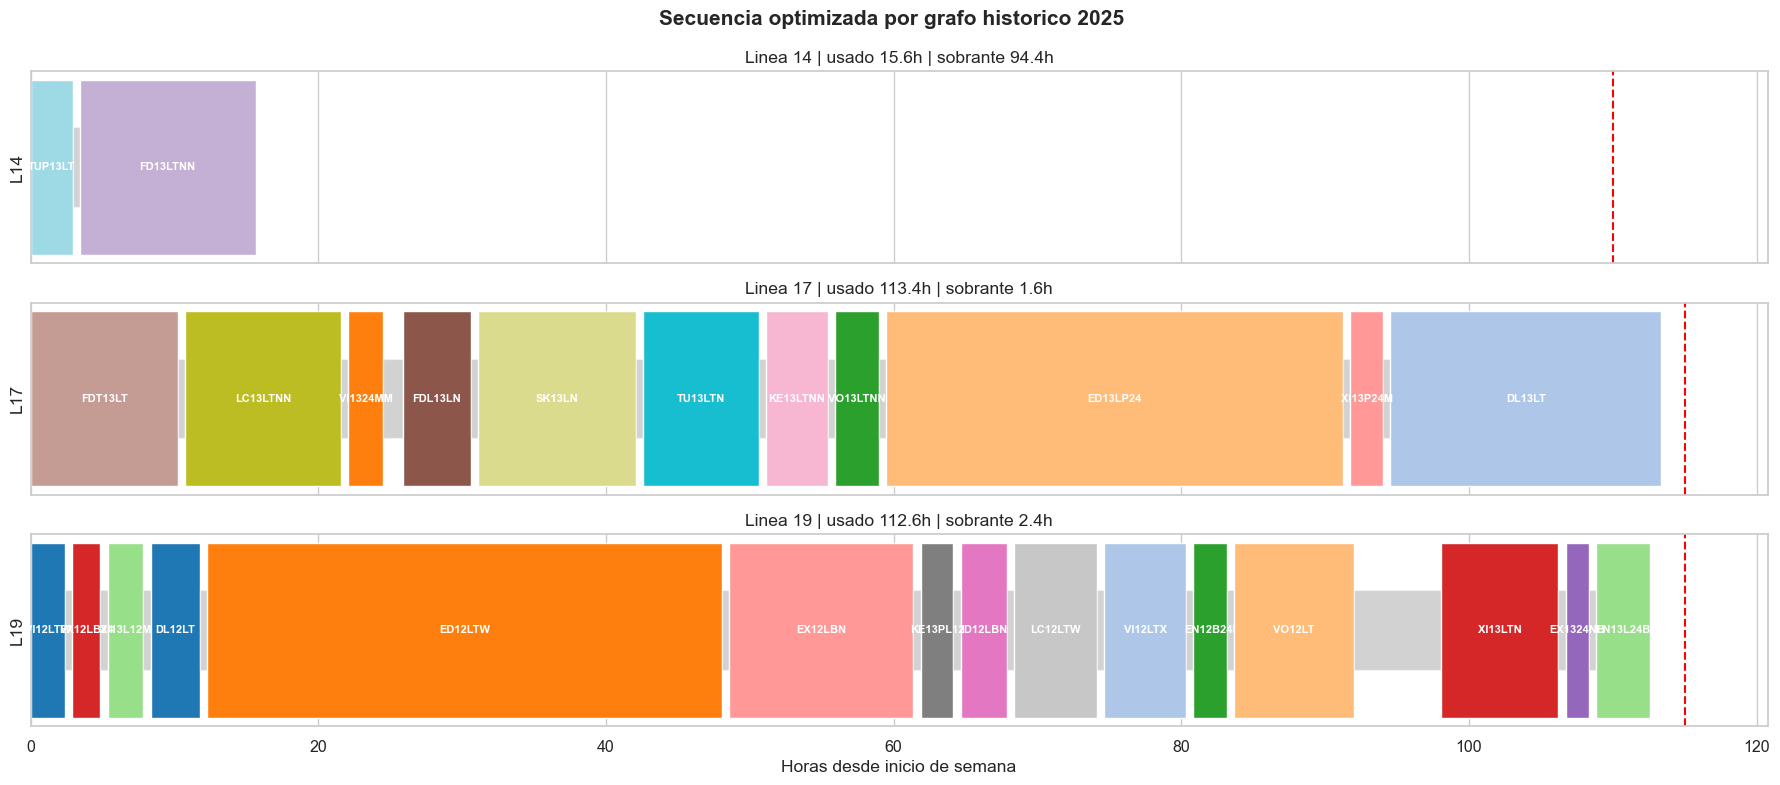

In [17]:
schedule_df = results['_schedule_df'].copy()
if schedule_df.empty:
    print('No hay schedule optimizado para visualizar.')
else:
    palette = dict(zip(sorted(schedule_df['sku'].unique()), sns.color_palette('tab20', n_colors=schedule_df['sku'].nunique())))
    fig, axes = plt.subplots(len(LINES), 1, figsize=(18, 8), sharex=True)
    if len(LINES) == 1:
        axes = [axes]
    for ax, line in zip(axes, LINES):
        det = schedule_df[schedule_df['line'] == line].sort_values('sequence_order')
        for _, item in det.iterrows():
            transition_h = float(item['transition_h'])
            prod_h = float(item['prod_h'])
            setup_start = max(float(item['start_h']) - transition_h, 0)
            if transition_h > 0:
                ax.barh(0, transition_h, left=setup_start, height=0.25, color='gray', alpha=0.35)
            ax.barh(0, prod_h, left=float(item['start_h']), height=0.55,
                    color=palette[item['sku']], edgecolor='white')
            if prod_h > 1.2:
                ax.text(float(item['start_h']) + prod_h / 2, 0, str(item['sku'])[:9],
                        ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        ax.axvline(HOURS_PER_WEEK[line], color='red', linestyle='--', lw=1.5)
        ax.set_title(f"Linea {line} | usado {results[line]['hours_optimized']:.1f}h | sobrante {results[line]['spare_hours']:.1f}h")
        ax.set_yticks([])
        ax.set_ylabel(f'L{line}')
    axes[-1].set_xlabel('Horas desde inicio de semana')
    plt.suptitle('Secuencia optimizada por grafo historico 2025', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 7 · Arcos del grafo usados por la solucion

In [18]:
for line in LINES:
    r = results.get(line)
    if not r or not r['seq_optimized']:
        continue
    print(f"\nLinea {line}")
    seq = r['seq_optimized']
    edge_hours = r['edge_hours']
    for origin, dest in zip(seq, seq[1:]):
        print(f"  {origin:<12} -> {dest:<12}  {edge_hours.loc[origin, dest]:5.2f} h")


Linea 14
  TUP13LT      -> FD13LTNN       0.50 h

Linea 17
  FDT13LT      -> LC13LTNN       0.50 h
  LC13LTNN     -> VI1324MM       0.50 h
  VI1324MM     -> FDL13LN        1.39 h
  FDL13LN      -> SK13LN         0.50 h
  SK13LN       -> TU13LTN        0.50 h
  TU13LTN      -> KE13LTNN       0.50 h
  KE13LTNN     -> VO13LTNN       0.50 h
  VO13LTNN     -> ED13LP24       0.50 h
  ED13LP24     -> XI13P24M       0.50 h
  XI13P24M     -> DL13LT         0.50 h

Linea 19
  VI12LTW      -> EX12LB24       0.52 h
  EX12LB24     -> XI13L12M       0.50 h
  XI13L12M     -> DL12LT         0.54 h
  DL12LT       -> ED12LTW        0.50 h
  ED12LTW      -> EX12LBN        0.50 h
  EX12LBN      -> KE13PL12       0.52 h
  KE13PL12     -> ID12LBN        0.53 h
  ID12LBN      -> LC12LTW        0.50 h
  LC12LTW      -> VI12LTX        0.50 h
  VI12LTX      -> EN12B24I       0.52 h
  EN12B24I     -> VO12LT         0.50 h
  VO12LT       -> XI13LTN        6.08 h
  XI13LTN      -> EX1324NB       0.52 h
  EX1324NB